In [1]:
# 📚 Core Libraries
import os
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms, models
from torchvision.models import resnet50, ResNet50_Weights

# 📊 Evaluation & Visualization
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, mean_squared_error, accuracy_score

# ✅ Device setup
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)


Using device: cpu


In [2]:
# 1️⃣ Define Dual Output Model (KL + Ahlbäck) using ResNet-50
class DualOutputCNN(nn.Module):
    def __init__(self):
        super(DualOutputCNN, self).__init__()
        # Load pretrained ResNet-50
        self.features = resnet50(weights=ResNet50_Weights.DEFAULT)
        
        # Replace the final fully connected layer with Identity (to extract features)
        self.features.fc = nn.Identity()
        
        # Add dual output heads
        self.fc_kl = nn.Sequential(
            nn.Linear(2048, 512),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(512, 5)  # KL Grades: 0–4
        )
        self.fc_ahlback = nn.Sequential(
            nn.Linear(2048, 512),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(512, 5)  # Ahlbäck Grades: 1–5 → mapped to 0–4
        )

    def forward(self, x):
        x = self.features(x)
        kl_out = self.fc_kl(x)
        ahl_out = self.fc_ahlback(x)
        return kl_out, ahl_out

# 2️⃣ Instantiate model
model = DualOutputCNN().to(device)


Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to C:\Users\Abhinav/.cache\torch\hub\checkpoints\resnet50-11ad3fa6.pth


100%|█████████████████████████████████████████████████████████████████████████████| 97.8M/97.8M [00:12<00:00, 8.47MB/s]


In [3]:
# 3️⃣ Image transforms with normalization and augmentation
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),  # 🆕 Augmentation
    transforms.RandomRotation(10),      # 🆕 Augmentation
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],  # ImageNet means
        std=[0.229, 0.224, 0.225]    # ImageNet stds
    )
])


In [4]:
# 4️⃣ Dataset and Loader Setup
data_dir = r"C:\Users\Abhinav\Downloads\KL and Ahlback"

train_dataset = datasets.ImageFolder(os.path.join(data_dir, "train"), transform=transform)
val_dataset = datasets.ImageFolder(os.path.join(data_dir, "val"), transform=transform)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)

# 5️⃣ Class label mapping like ['0_1', '1_2', ...]
class_map = train_dataset.classes
print("Detected Classes:", class_map)


Detected Classes: ['0_1', '1_2', '2_3', '3_4', '4_5']


In [5]:
# 6️⃣ Loss and optimizer
criterion = nn.CrossEntropyLoss()

# 🧠 Adam optimizer with weight decay (helps reduce overfitting)
optimizer = optim.Adam(model.parameters(), lr=1e-4, weight_decay=1e-5)


In [6]:
# 7️⃣ Training loop
num_epochs = 50
patience = 5
wait = 0
best_loss = float("inf")
train_losses = []

for epoch in range(num_epochs):
    model.train()
    total_loss = 0

    for imgs, labels in train_loader:
        imgs = imgs.to(device)
        labels = labels.to(device)

        # Extract KL and Ahlbäck grades
        kl_labels = torch.tensor([int(class_map[l].split("_")[0]) for l in labels]).to(device)
        ahl_labels = torch.tensor([int(class_map[l].split("_")[1]) - 1 for l in labels]).to(device)

        kl_out, ahl_out = model(imgs)

        # Combined loss
        loss_kl = criterion(kl_out, kl_labels)
        loss_ahl = criterion(ahl_out, ahl_labels)
        loss = loss_kl + loss_ahl

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    avg_loss = total_loss / len(train_loader)
    train_losses.append(avg_loss)
    print(f"📘 Epoch [{epoch+1}/{num_epochs}] - Train Loss: {avg_loss:.4f}")

    # 🔐 Save best model
    if avg_loss < best_loss:
        best_loss = avg_loss
        torch.save(model.state_dict(), "best_resnet50_model.pth")
        print("✅ Best model saved.")
        wait = 0
    else:
        wait += 1


📘 Epoch [1/50] - Train Loss: 2.4743
✅ Best model saved.
📘 Epoch [2/50] - Train Loss: 1.8569
✅ Best model saved.
📘 Epoch [3/50] - Train Loss: 1.6400
✅ Best model saved.
📘 Epoch [4/50] - Train Loss: 1.5212
✅ Best model saved.
📘 Epoch [5/50] - Train Loss: 1.4307
✅ Best model saved.
📘 Epoch [6/50] - Train Loss: 1.3729
✅ Best model saved.
📘 Epoch [7/50] - Train Loss: 1.2970
✅ Best model saved.
📘 Epoch [8/50] - Train Loss: 1.2485
✅ Best model saved.
📘 Epoch [9/50] - Train Loss: 1.1614
✅ Best model saved.
📘 Epoch [10/50] - Train Loss: 1.0837
✅ Best model saved.
📘 Epoch [11/50] - Train Loss: 1.0029
✅ Best model saved.
📘 Epoch [12/50] - Train Loss: 0.9251
✅ Best model saved.
📘 Epoch [13/50] - Train Loss: 0.8597
✅ Best model saved.
📘 Epoch [14/50] - Train Loss: 0.7583
✅ Best model saved.
📘 Epoch [15/50] - Train Loss: 0.6799
✅ Best model saved.
📘 Epoch [16/50] - Train Loss: 0.6152
✅ Best model saved.
📘 Epoch [17/50] - Train Loss: 0.5303
✅ Best model saved.
📘 Epoch [18/50] - Train Loss: 0.4915
✅ B

✅ KL Grade Accuracy: 0.6416464891041163
✅ Ahlbäck Grade Accuracy: 0.6428571428571429

📊 KL Grade Classification Report:
               precision    recall  f1-score   support

           0       0.68      0.78      0.73       328
           1       0.37      0.24      0.29       153
           2       0.60      0.66      0.63       212
           3       0.82      0.71      0.76       106
           4       0.88      0.81      0.85        27

    accuracy                           0.64       826
   macro avg       0.67      0.64      0.65       826
weighted avg       0.63      0.64      0.63       826


📊 Ahlbäck Grade Classification Report:
               precision    recall  f1-score   support

           0       0.68      0.78      0.72       328
           1       0.38      0.24      0.29       153
           2       0.60      0.66      0.63       212
           3       0.83      0.72      0.77       106
           4       0.88      0.85      0.87        27

    accuracy           

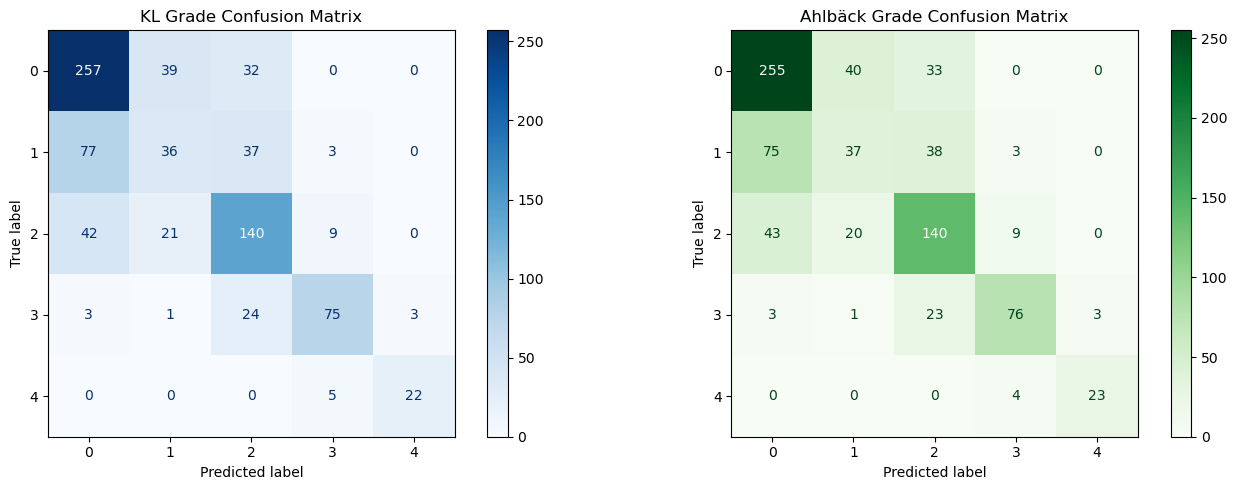

In [10]:
# 8️⃣ Evaluation on Validation Set
model.load_state_dict(torch.load("best_resnet50_model.pth"))
model.eval()

all_kl_preds = []
all_ahl_preds = []
all_kl_true = []
all_ahl_true = []

with torch.no_grad():
    for imgs, labels in val_loader:
        imgs = imgs.to(device)
        labels = labels.to(device)

        kl_labels = torch.tensor([int(class_map[l].split("_")[0]) for l in labels]).to(device)
        ahl_labels = torch.tensor([int(class_map[l].split("_")[1]) - 1 for l in labels]).to(device)

        kl_out, ahl_out = model(imgs)

        kl_preds = torch.argmax(kl_out, dim=1)
        ahl_preds = torch.argmax(ahl_out, dim=1)

        all_kl_preds.extend(kl_preds.cpu().numpy())
        all_ahl_preds.extend(ahl_preds.cpu().numpy())
        all_kl_true.extend(kl_labels.cpu().numpy())
        all_ahl_true.extend(ahl_labels.cpu().numpy())

# 🔎 Print Accuracy
print("✅ KL Grade Accuracy:", accuracy_score(all_kl_true, all_kl_preds))
print("✅ Ahlbäck Grade Accuracy:", accuracy_score(all_ahl_true, all_ahl_preds))

# 📄 Classification Reports
print("\n📊 KL Grade Classification Report:\n", classification_report(all_kl_true, all_kl_preds))
print("\n📊 Ahlbäck Grade Classification Report:\n", classification_report(all_ahl_true, all_ahl_preds))

# 📉 Confusion Matrices
fig, axs = plt.subplots(1, 2, figsize=(14, 5))

ConfusionMatrixDisplay.from_predictions(all_kl_true, all_kl_preds, ax=axs[0], cmap='Blues')
axs[0].set_title("KL Grade Confusion Matrix")

ConfusionMatrixDisplay.from_predictions(all_ahl_true, all_ahl_preds, ax=axs[1], cmap='Greens')
axs[1].set_title("Ahlbäck Grade Confusion Matrix")

plt.tight_layout()
plt.show()


C:\Users\Abhinav\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 129460 (\N{BONE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


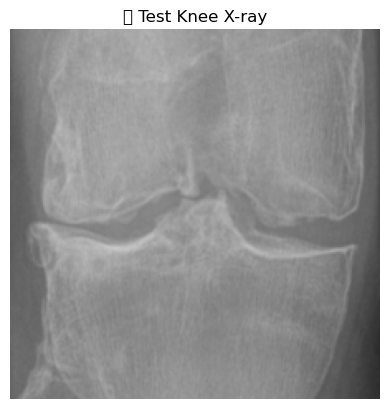

🧠 Predicted KL Grade: 3
🦴 Predicted Ahlbäck Grade: Grade 4
📏 Estimated Joint Space Width: 1.00 mm


In [11]:
from PIL import Image
import torchvision.transforms as transforms
import matplotlib.pyplot as plt

# 🔍 Path to test image
test_img_path = r"C:\Users\Abhinav\Downloads\KL and Ahlback\test\3_4\9998384R.png"  # Update path if needed

# 📥 Load and preprocess image
test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],  # ImageNet normalization
        std=[0.229, 0.224, 0.225]
    )
])

# Load image and display
test_img = Image.open(test_img_path).convert("RGB")
plt.imshow(test_img)
plt.axis("off")
plt.title("🦴 Test Knee X-ray")
plt.show()

# Apply transform and prepare batch
input_tensor = test_transform(test_img).unsqueeze(0).to(device)

# 🔮 Predict
model.eval()
with torch.no_grad():
    kl_out, ahl_out = model(input_tensor)
    kl_pred = kl_out.argmax(dim=1).item()
    ahl_pred = ahl_out.argmax(dim=1).item() + 1  # Ahlbäck: 0–4 → Grade 1–5

# 📢 Show predictions
print(f"🧠 Predicted KL Grade: {kl_pred}")
print(f"🦴 Predicted Ahlbäck Grade: Grade {ahl_pred}")

# 📏 Simulated Joint Space Width (for reference only)
def kl_to_jsw(kl):
    mapping = {
        0: 4.0,
        1: 3.0,
        2: 2.0,
        3: 1.0,
        4: 0.5
    }
    return mapping.get(kl, 2.5)

predicted_jsw = kl_to_jsw(kl_pred)
print(f"📏 Estimated Joint Space Width: {predicted_jsw:.2f} mm")


C:\Users\Abhinav\anaconda3\Lib\site-packages\torch\nn\modules\module.py:1842: FutureWarning: Using a non-full backward hook when the forward contains multiple autograd Nodes is deprecated and will be removed in future versions. This hook will be missing some grad_input. Please use register_full_backward_hook to get the documented behavior.
  self._maybe_warn_non_full_backward_hook(args, result, grad_fn)
C:\Users\Abhinav\AppData\Local\Temp\ipykernel_11844\235885958.py:84: UserWarning: Glyph 128293 (\N{FIRE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Abhinav\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128293 (\N{FIRE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


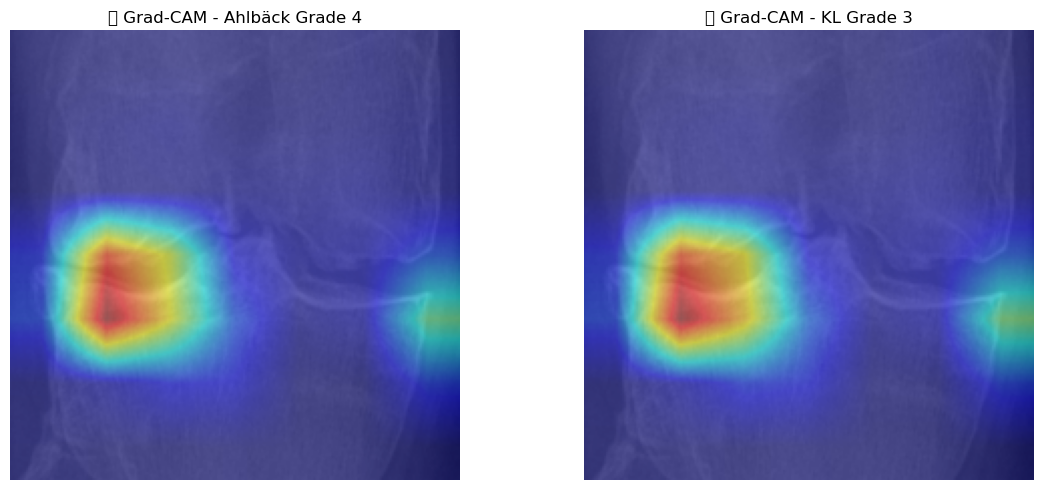

In [12]:
import cv2
import numpy as np
import torch.nn.functional as F

def generate_gradcam(model, image_tensor, target_layer, branch="ahlback", class_index=0):
    model.eval()
    gradients = []
    activations = []

    def backward_hook(module, grad_input, grad_output):
        gradients.append(grad_output[0])

    def forward_hook(module, input, output):
        activations.append(output)

    # Register forward & backward hooks
    h_b = target_layer.register_backward_hook(backward_hook)
    h_f = target_layer.register_forward_hook(forward_hook)

    # Forward pass
    kl_out, ahl_out = model(image_tensor)

    # Select appropriate output branch
    output = ahl_out if branch == "ahlback" else kl_out
    class_score = output[:, class_index]

    # Backward pass
    model.zero_grad()
    class_score.backward()

    # Extract activations and gradients
    grads = gradients[0].detach()
    acts = activations[0].detach()
    pooled_grads = torch.mean(grads, dim=[0, 2, 3])

    for i in range(acts.shape[1]):
        acts[:, i, :, :] *= pooled_grads[i]

    heatmap = acts.sum(dim=1).squeeze()
    heatmap = F.relu(heatmap)
    heatmap /= heatmap.max()

    heatmap = heatmap.cpu().numpy()
    heatmap = cv2.resize(heatmap, (224, 224))
    heatmap = np.uint8(255 * heatmap)
    heatmap_color = cv2.applyColorMap(heatmap, cv2.COLORMAP_JET)

    # Convert input tensor to displayable image
    img = image_tensor.squeeze().permute(1, 2, 0).cpu().numpy()
    img = img * np.array([0.229, 0.224, 0.225]) + np.array([0.485, 0.456, 0.406])  # De-normalize
    img = np.clip(img, 0, 1)
    img = np.uint8(255 * img)
    img = cv2.cvtColor(img, cv2.COLOR_RGB2BGR)

    overlayed = cv2.addWeighted(img, 0.5, heatmap_color, 0.5, 0)

    # Remove hooks
    h_b.remove()
    h_f.remove()

    return overlayed

# 🔥 Generate Grad-CAMs for predicted classes
gradcam_ahlback = generate_gradcam(
    model, input_tensor, model.features.layer4, branch="ahlback", class_index=ahl_pred - 1
)
gradcam_kl = generate_gradcam(
    model, input_tensor, model.features.layer4, branch="kl", class_index=kl_pred
)

# 🖼️ Show both Grad-CAMs
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.imshow(cv2.cvtColor(gradcam_ahlback, cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.title(f"🔥 Grad-CAM - Ahlbäck Grade {ahl_pred}")

plt.subplot(1, 2, 2)
plt.imshow(cv2.cvtColor(gradcam_kl, cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.title(f"🔥 Grad-CAM - KL Grade {kl_pred}")

plt.tight_layout()
plt.show()


In [13]:
def describe_joint_condition(kl_grade, ahlback_grade):
    symptoms = [
        "Pain during movement or after prolonged activity.",
        "Joint stiffness, especially in the morning.",
        "Swelling or warmth around the knee.",
        "Crackling or grinding sounds.",
        "Difficulty in bending or straightening the knee."
    ]

    # KL Grading Descriptions (0–4)
    kl_descriptions = {
        0: {
            "stage": "No signs of osteoarthritis",
            "treatment": ["Maintain healthy weight", "Stay active with low-impact exercises"],
            "precautions": ["Avoid high-impact sports"]
        },
        1: {
            "stage": "Doubtful joint space narrowing; possible osteophytes",
            "treatment": ["Physical therapy", "Light strengthening exercises"],
            "precautions": ["Avoid overuse and repetitive motion"]
        },
        2: {
            "stage": "Definite osteophytes and possible joint space narrowing",
            "treatment": ["NSAIDs for pain", "Activity modification", "Low-impact workouts"],
            "precautions": ["Monitor for worsening symptoms"]
        },
        3: {
            "stage": "Moderate joint space reduction; multiple osteophytes",
            "treatment": ["Injections (e.g., corticosteroids)", "Supportive devices", "Targeted rehab"],
            "precautions": ["Avoid climbing stairs", "Use joint support if needed"]
        },
        4: {
            "stage": "Severe joint space loss; large osteophytes and sclerosis",
            "treatment": ["Surgical consideration (e.g., knee replacement)", "Comprehensive pain management"],
            "precautions": ["Avoid weight-bearing stress", "Use mobility aids"]
        }
    }

    # Ahlbäck Grading Descriptions (1–5)
    ahl_descriptions = {
        1: {
            "severity": "Grade I: Joint space narrowing without bone damage.",
            "treatment": ["Lifestyle change", "Anti-inflammatory meds", "Regular physiotherapy"],
            "precautions": ["Avoid high-impact activity"]
        },
        2: {
            "severity": "Grade II: Complete joint space loss, no bone collapse yet.",
            "treatment": ["Pain relief injections", "Custom braces", "ROM exercises"],
            "precautions": ["Minimize stair use", "Don't overload joint"]
        },
        3: {
            "severity": "Grade III: Bone loss less than 5 mm.",
            "treatment": ["Supportive devices", "Advanced rehab", "Pain management"],
            "precautions": ["No squatting/kneeling", "Monitor for collapse"]
        },
        4: {
            "severity": "Grade IV: Bone loss between 5–10 mm.",
            "treatment": ["Surgical consult", "Assistive walking tools"],
            "precautions": ["Schedule rest intervals", "Avoid prolonged standing"]
        },
        5: {
            "severity": "Grade V: Bone loss over 10 mm and joint deformity.",
            "treatment": ["Total knee replacement", "Post-surgery rehab", "Strong pain meds"],
            "precautions": ["Avoid risky movement", "Modify home environment"]
        }
    }

    # 📢 Print Detailed Clinical Interpretation
    print("\n🦴 Common Symptoms Observed in Osteoarthritis:")
    for s in symptoms:
        print(f"  • {s}")

    # KL Interpretation
    if kl_grade in kl_descriptions:
        kl_info = kl_descriptions[kl_grade]
        print(f"\n📘 KL Grade {kl_grade} Interpretation:")
        print(f"  • Stage: {kl_info['stage']}")
        print(f"  • Recommended Treatment:")
        for t in kl_info["treatment"]:
            print(f"    - {t}")
        print(f"  • Precautions:")
        for p in kl_info["precautions"]:
            print(f"    - {p}")
    else:
        print(f"\n⚠️ KL Grade {kl_grade} is out of valid range (0–4).")

    # Ahlbäck Interpretation
    if ahlback_grade in ahl_descriptions:
        ahl_info = ahl_descriptions[ahlback_grade]
        print(f"\n📗 Ahlbäck Grade {ahlback_grade} Interpretation:")
        print(f"  • Severity: {ahl_info['severity']}")
        print(f"  • Recommended Treatment:")
        for t in ahl_info["treatment"]:
            print(f"    - {t}")
        print(f"  • Precautions:")
        for p in ahl_info["precautions"]:
            print(f"    - {p}")
    else:
        print(f"\n⚠️ Ahlbäck Grade {ahlback_grade} is out of valid range (1–5).")

# 📞 Use after inference
describe_joint_condition(kl_pred, ahl_pred)



🦴 Common Symptoms Observed in Osteoarthritis:
  • Pain during movement or after prolonged activity.
  • Joint stiffness, especially in the morning.
  • Swelling or warmth around the knee.
  • Crackling or grinding sounds.
  • Difficulty in bending or straightening the knee.

📘 KL Grade 3 Interpretation:
  • Stage: Moderate joint space reduction; multiple osteophytes
  • Recommended Treatment:
    - Injections (e.g., corticosteroids)
    - Supportive devices
    - Targeted rehab
  • Precautions:
    - Avoid climbing stairs
    - Use joint support if needed

📗 Ahlbäck Grade 4 Interpretation:
  • Severity: Grade IV: Bone loss between 5–10 mm.
  • Recommended Treatment:
    - Surgical consult
    - Assistive walking tools
  • Precautions:
    - Schedule rest intervals
    - Avoid prolonged standing


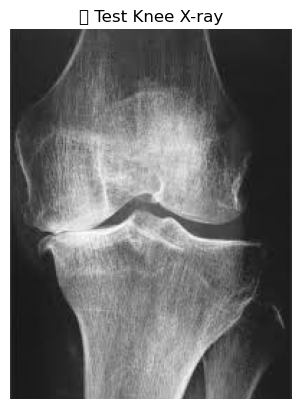

🧠 Predicted KL Grade: 4
🦴 Predicted Ahlbäck Grade: Grade 5
📏 Estimated Joint Space Width: 0.50 mm


In [14]:
from PIL import Image
import torchvision.transforms as transforms
import matplotlib.pyplot as plt

# 🔍 Path to test image
test_img_path = r"C:\Users\Abhinav\Downloads\images.jpeg"  # Update path if needed

# 📥 Load and preprocess image
test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],  # ImageNet normalization
        std=[0.229, 0.224, 0.225]
    )
])

# Load image and display
test_img = Image.open(test_img_path).convert("RGB")
plt.imshow(test_img)
plt.axis("off")
plt.title("🦴 Test Knee X-ray")
plt.show()

# Apply transform and prepare batch
input_tensor = test_transform(test_img).unsqueeze(0).to(device)

# 🔮 Predict
model.eval()
with torch.no_grad():
    kl_out, ahl_out = model(input_tensor)
    kl_pred = kl_out.argmax(dim=1).item()
    ahl_pred = ahl_out.argmax(dim=1).item() + 1  # Ahlbäck: 0–4 → Grade 1–5

# 📢 Show predictions
print(f"🧠 Predicted KL Grade: {kl_pred}")
print(f"🦴 Predicted Ahlbäck Grade: Grade {ahl_pred}")

# 📏 Simulated Joint Space Width (for reference only)
def kl_to_jsw(kl):
    mapping = {
        0: 4.0,
        1: 3.0,
        2: 2.0,
        3: 1.0,
        4: 0.5
    }
    return mapping.get(kl, 2.5)

predicted_jsw = kl_to_jsw(kl_pred)
print(f"📏 Estimated Joint Space Width: {predicted_jsw:.2f} mm")
